# Gym Exercise Classification via Wearable Sensor Data

**Multi-class supervised classification of 11 gym exercises using IMU and HBC sensor signals.**

Dataset: [RecGym — UCI ML Repository](https://archive.uci.edu/dataset/1128) | Kaggle | GitHub (see README for links)


# **Table of Contents**

- **Introduction**

    - Dataset Background and Motivation

    - Classification Task Definition

    - Aim and Objectives

- **Dataset Overview**

    -Sensor Configuration and Data Collection

    - Class Definitions and Label Encoding

- **Preprocessing the Data**

    - Data Loading and Initial Inspection

    - Removal of Null-labelled Samples

    - Exploratory Data Characteristics

        - Class Distribution

        - Feature Range and Variability

    - Outlier Removal using Within-class Z-score

    - Feature Normalization (Min-Max Scaling to [-1, 1])

    - Signal Smoothing using Moving Average

- **Machine Learning Models and Experimental Setup**

    - Feature Selection

    - Train–Test Split
 
    - Evaluation Metrics

- **Baseline Models**

    - Naive Bayes

    - Logistic Regression

    - Support Vector Machine

- **Tree-based and Distance-based Models**

    - Decision Tree

    - k-Nearest Neighbors

    - Random Forest

-**Make a new Algorithm!!: Use Ensemble**

 - XGBoost

 - LightGBM

 - Weighted Soft Voting Ensemble


- **Results and Comparative Analysis**

    - Model Performance Comparison

    - Feature Importance Analysis

- **Conclusion and Critical Evaluation**

    - Summary of Findings

    - Limitations and Future Work

- **References**

## **1.Introduction**

In this project, the analysis is based on the same original dataset, which is available on multiple platforms. Specifically, the RecGym: Gym Workouts Recognition Dataset (comprising IMU and HBC sensors) can be accessed from the following sources: UCI Machine Learning Repository(https://archive.ics.uci.edu/dataset/1128/recgym:+gym+workouts+recognition+dataset+with+imu+and+capacitive+sensor-7), GitHub repository(https://github.com/zhaxidele/Toolkit-for-HBC-sensing/tree/main/Data/GymData), and Kaggle dataset(https://www.kaggle.com/datasets/zhaxidelebsz/10-gym-exercises-with-615-abstracted-features). This dataset consists of time-series recordings collected from 10 participants performing various gym exercises using wearable sensors, and it includes clearly labeled segments suitable for supervised learning tasks in exercise classification.

I explore the classification of gym exercises using wearable sensor data. The dataset contains recordings from 10 participants performing various exercises, captured with both Inertial Measurement Units (IMU) and Human Body Capacitance (HBC) sensors. Each session includes labeled segments for multiple exercise types, making it suitable for supervised classification tasks.

My goal is to apply different classification algorithms to distinguish between exercise types based on sensor data. By visualizing the data and examining the relationships between sensor readings and exercise labels, I aim to better understand how sensor signals can be used to identify physical activities.

### **Classification Task Definition**

In this project, gym exercise recognition is formulated as a multi-class supervised classification problem. Each data sample corresponds to a segmented time window of wearable sensor signals, represented by a feature vector consisting of accelerometer readings consisting of accelerometer readings 
(𝐴𝑥, 𝐴𝑦, 𝐴𝑧), gyroscope readings 
(𝐺𝑥, 𝐺𝑦, 𝐺𝑧), and a Human Body Capacitance sensor value 
(𝐶1).
	​
The target variable, Workout, indicates the type of physical activity being performed during the corresponding time window. For model training, categorical workout labels are encoded as numerical class labels. For example, class 0 represents idle or non-exercise activity (Null), while other class indices correspond to specific gym exercises such as Arm Curl, Bench Press, Squat, Walking, and Running.

The objective of the classifier is to learn a mapping from the sensor feature space to these discrete activity classes, enabling automatic identification of exercise type based on wearable sensor data.

## **Aim**
The aim of this project is **1. to evaluate and compare multiple classification algorithms** in order to identify the most effective model for recognizing gym exercises using wearable sensor data, and **2. to analyse the relative importance of sensor features** contributing to classification performance.

### **Object 1**
To compare the performance of multiple supervised classification algorithms (Logistic Regression, Decision Tree, SVM, k-NN, and Random Forest) using 7 sensor features (6 IMU axes + 1 HBC signal) features after removing Null-labelled samples, and to identify the best-performing model based on quantitative evaluation metrics such as accuracy, precision, recall, and F1-score.


### **Object 2**
To investigate the relative importance of individual sensor features (accelerometer, gyroscope, and HBC signals) in exercise classification by analysing feature importance scores derived from tree-based models and examining how different sensor modalities contribute to classification performance.

## **Object 3**
To achieve the best classification performance by designing a weighted soft-voting ensemble that integrates multiple machine learning algorithms with complementary strengths.

## **2. Data Set Overview**
This dataset was originally collected to evaluate Human Body Capacitance (HBC) as a wearable motion-sensing modality and to compare it with standard Inertial Measurement Unit (IMU) data. In this project, the dataset is used for supervised multi-class exercise classification based on wearable sensor signals. Target activities include Arm Curl, Bench Press, Squat, Running, Walking, and other resistance and aerobic exercises, with multiple sets and durations per session.

The dataset contains the following sensor feature columns:

- `A_x, A_y, A_z`: Accelerometer readings along the x, y, and z axes  
- `G_x, G_y, G_z`: Gyroscope readings along the x, y, and z axes  
- `C_1`: Human Body Communication (HBC) sensor value representing changes in body capacitance

#### **Workout Label Encoding**

Each workout class is encoded with an **explicitly defined integer label**, as shown below.

| Class ID | Workout Type     |
|---------:|------------------|
| 0        | Adductor         |
| 1        | ArmCurl          |
| 2        | BenchPress       |
| 3        | LegCurl          |
| 4        | LegPress         |
| 5        | Riding           |
| 6        | RopeSkipping     |
| 7        | Running          |
| 8        | Squat            |
| 9        | StairClimber     |
| 10       | Walking          |

Actually, Null was present in the raw dataset but excluded from this coursework. Therefore the final task uses 11 exercise classes(0 to 10).


## Part 1. Preprocessing the data

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('RecGym.csv')
df.head() # 5 rows check

,Subject,Position,Session,A_x,A_y,A_z,G_x,G_y,G_z,C_1,Workout
0,1,wrist,1,0.501125,0.500625,0.500500,0.500156,0.499962,0.500313,0.501227,Null
1,1,wrist,1,0.500250,0.499750,0.501250,0.499531,0.500550,0.500081,0.501584,Null
2,1,wrist,1,0.500250,0.499375,0.501875,0.499613,0.500231,0.500119,0.501508,Null
3,1,wrist,1,0.499625,0.499750,0.500875,0.499494,0.500350,0.500588,0.502032,Null
4,1,wrist,1,0.500000,0.499000,0.501000,0.499650,0.500588,0.499769,0.501756,Null


In [3]:
#preprocessing
df["Workout"].unique().tolist()

['Null',
 'LegCurl',
 'Squat',
 'Adductor',
 'LegPress',
 'ArmCurl',
 'BenchPress',
 'RopeSkipping',
 'Walking',
 'Running',
 'StairClimber',
 'Riding']

In [4]:
#To examine the data in more detail, we looked at the key values.
keys=df.keys()
print("Gym data keys: " ,keys)

Gym data keys:  Index(['Subject', 'Position', 'Session', 'A_x', 'A_y', 'A_z', 'G_x', 'G_y',
       'G_z', 'C_1', 'Workout'],
      dtype='object')


### **Preprocessing - Remove the Null value**

The 'Null' values were removed because the focus of the analysis is on distinguishing different types of exercises. Since 'Null' does not correspond to any actual exercise, it was unnecessary for the purpose of activity classification.
The string `'Null'` values in the dataset were replaced with `NaN` and subsequently removed.


In [5]:
import numpy as np

df["Workout"] = df["Workout"].replace("Null", np.nan)
df = df.dropna(subset=["Workout"])

In [6]:
df.head()

,Subject,Position,Session,A_x,A_y,A_z,G_x,G_y,G_z,C_1,Workout
476,1,wrist,1,0.499875,0.500375,0.501500,0.499337,0.500550,0.499725,0.501602,LegCurl
477,1,wrist,1,0.503000,0.498250,0.501000,0.500194,0.500663,0.499919,0.501452,LegCurl
478,1,wrist,1,0.498500,0.501250,0.500750,0.497069,0.501794,0.499569,0.501369,LegCurl
479,1,wrist,1,0.499750,0.499625,0.501125,0.498787,0.501444,0.499688,0.501086,LegCurl
480,1,wrist,1,0.498625,0.498625,0.502375,0.498244,0.501094,0.499806,0.501045,LegCurl


## EDA

**Why Exploratory Data Analysis (EDA) is Performed**

Exploratory Data Analysis (EDA) is performed to gain an initial understanding of the dataset before applying machine learning models.
In this project, EDA is used to examine the distribution of exercise classes, check the overall scale and variability of sensor features, and identify potential issues such as class imbalance or abnormal values.
This step helps verify that the data are suitable for supervised classification and provides justification for subsequent preprocessing choices, including outlier removal, normalisation, and the selection of evaluation metrics.

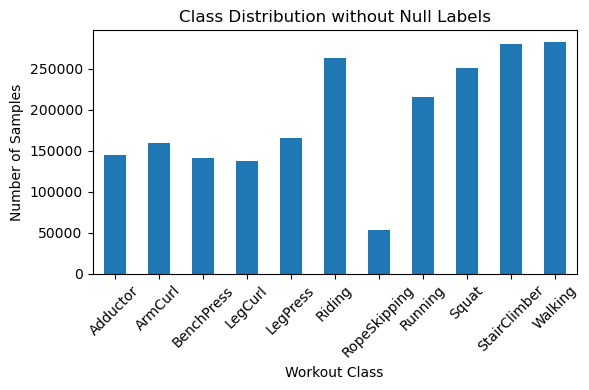

In [18]:
#Class Distribution
import matplotlib.pyplot as plt

class_counts = df["Workout"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution without Null Labels")
plt.ylabel("Number of Samples")
plt.xlabel("Workout Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The figure shows the distribution of workout classes after removing the Null (idle) labels.
Although the dataset is not perfectly balanced, all exercise classes contain a substantial number of samples, which makes the dataset suitable for supervised multi-class classification.
Activities such as Walking, StairClimber, Riding, and Squat have relatively larger sample sizes, while RopeSkipping has fewer samples compared to other classes.
This class imbalance is considered during model evaluation by reporting macro-averaged and weighted performance metrics.

In [19]:
df[SENSOR_COLS].describe()

,A_x,A_y,A_z,G_x,G_y,G_z,C_1
count,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06
mean,5.054836e-01,4.978843e-01,4.971876e-01,4.993472e-01,4.994895e-01,5.001559e-01,4.999752e-01
std,5.808903e-02,6.650859e-02,3.965593e-02,5.255546e-02,4.633910e-02,5.962683e-02,5.119321e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.931250e-01,4.875000e-01,4.908750e-01,4.898062e-01,4.904312e-01,4.823438e-01,4.968764e-01
50%,5.001250e-01,4.995000e-01,4.997500e-01,4.999188e-01,5.000375e-01,4.999188e-01,5.000206e-01
75%,5.133750e-01,5.085000e-01,5.058750e-01,5.095688e-01,5.094562e-01,5.149625e-01,5.031632e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


### **Preprocessing - Removing the outliers**

---

After examining the distribution of sensor values for each exercise class during the exploratory analysis, I observed that some samples contained extreme values. These extreme values are likely caused by temporary factors such as brief sensor shaking, loose device placement, or abnormal exertion during a short time window.

Such values do not represent the typical motion pattern of an exercise. Instead, they act as transient noise and may distort the learning process by forcing the model to adapt to rare and unrepresentative cases. In particular, these extreme samples can unnecessarily widen decision boundaries, which negatively affects the model’s ability to generalise to unseen data.

To address this issue, I applied a class-wise outlier removal strategy based on z-score normalisation. The procedure is as follows:

For each sensor feature, the mean (μ) and standard deviation (σ) are computed within each exercise class separately.

The z-score is then calculated as:

z = (f − μ) / σ
	​


Samples with an absolute z-score greater than 3 (|z| > 3) are treated as outliers and removed.

The threshold of 3 is based on a common statistical heuristic, where approximately 99.7% of values in a normal distribution fall within ±3 standard deviations. Values beyond this range are therefore considered highly unlikely to represent normal behaviour.

By performing outlier removal within each class, I ensure that the natural differences between exercises are preserved. For example, exercises such as RopeSkipping naturally exhibit higher signal magnitudes than exercises like LegPress, and these inter-class differences are retained. Only unusually extreme values within the same exercise class are discarded.

In summary, this approach removes abnormal spikes while preserving meaningful class-level characteristics. As a result, the model is encouraged to learn the typical sensor patterns of each exercise rather than fitting to rare, noisy observations.


In [20]:
from scipy.stats import zscore

SENSOR_COLS = ["A_x","A_y","A_z","G_x","G_y","G_z","C_1"]

def remove_outliers_by_class_zscore(df, cols, label_col="Workout", z_thresh=3.0):
    work = df.copy()
    mask = np.ones(len(work), dtype=bool)

    for c in cols:
        z = work.groupby(label_col)[c].transform(zscore)
        mask &= np.abs(z) <= z_thresh

    filtered = work[mask].copy()
    return filtered, int((~mask).sum())

feat_filtered, removed_n = remove_outliers_by_class_zscore(df, SENSOR_COLS, "Workout", 3.0)
print("Before:", len(df))
print("After :", len(feat_filtered))
print("Outliers removed:", removed_n)


Before: 2096209
After : 1898653
Outliers removed: 197556


- After comparing the dataset size before and after filtering, this procedure ensures that outliers have been properly removed before proceeding to the next step.

### **Preprocessing - Data Normalization (Min-Max Scaling to [-1, 1])**

In this project, I applied both z-score normalisation and Min–Max scaling, each serving a different purpose within the preprocessing pipeline. Z-scores were used only to detect outliers, and the actual model inputs were scaled using Min–Max scaling.

First, z-score normalisation was used as part of the outlier detection process, rather than as a final feature scaling method for model training. By computing the mean (μ) and standard deviation (σ) within each exercise class, z-scores allowed me to identify values that deviated abnormally from the typical pattern of the same exercise. This step was specifically designed to detect and remove rare, unrepresentative spikes caused by transient sensor noise, such as brief device shaking or irregular movement.

After removing these extreme values, Min–Max scaling was applied to the cleaned dataset to prepare the features for machine learning models. The purpose of Min–Max scaling is different from that of z-score normalisation: it ensures that all sensor features share a common numerical range. Since accelerometer, gyroscope, and HBC signals may differ in magnitude, scaling them to the range [-1, 1] prevents features with larger numeric ranges from dominating the learning process.

Min–Max scaling was chosen for the final normalisation step because the prior outlier removal ensured that the remaining minimum and maximum values were representative of typical sensor behaviour. This approach preserves the relative shape of each feature distribution while providing stable inputs for distance-based and optimisation-based models, such as k-Nearest Neighbours and ensemble methods.

In summary, z-score normalisation was used analytically to detect outliers, while Min–Max scaling was used numerically to standardise feature ranges for model training. Applying both methods sequentially allows the preprocessing pipeline to remove abnormal noise while maintaining stable and comparable feature scales.

In [21]:
from sklearn.preprocessing import MinMaxScaler

feat_norm = feat_filtered.copy()

scaler = MinMaxScaler(feature_range=(-1, 1))
feat_norm[SENSOR_COLS] = scaler.fit_transform(feat_norm[SENSOR_COLS])

### **Preprocessing – Smoothing the Data**

After feature scaling, I applied a **moving average smoothing** technique to each sensor feature to further reduce short-term noise and stabilise the input signals used for classification.

Wearable sensor data often contain small, high-frequency fluctuations caused by minor hand tremors, sensor jitter, or brief inconsistencies in device placement. While these fluctuations are not necessarily outliers, they can introduce unnecessary variability at the window level and make it more difficult for classification models to capture consistent exercise patterns. This issue becomes more prominent when multiple consecutive windows correspond to the same physical activity.

To address this, I applied a simple moving average smoothing method. The smoothed signal \( y[i] \) is computed as the average of the most recent \( k \) samples:

- \( x[i] \) represents the original feature value at the current time window  
- \( k \) denotes the window size (in this project, \( k = 3 \))  
- For the first \( k-1 \) samples, the average is computed using the available preceding values  

This method reduces short-term fluctuations while preserving the overall trend of the sensor signal. As a result, the dominant motion patterns associated with each exercise remain intact, while small, irregular variations are attenuated.

A moving average was selected over more complex smoothing techniques, such as exponential smoothing, for practical reasons. It does not introduce additional parameters that require tuning, is computationally efficient, and can be implemented in a fully vectorised manner using NumPy operations. This is particularly important given the large scale of the dataset used in this project.

Overall, this smoothing step improves signal stability at the window level and supports more robust pattern learning in subsequent classification models.

#### **Advantages of Moving Average Smoothing**

- **Noise Reduction**: Reduces short-term fluctuations in accelerometer, gyroscope, and HBC signals.  
- **Trend Preservation**: Maintains the dominant motion patterns of each exercise while filtering out minor jitter.  
- **Computational Efficiency**: Avoids recursive computations and scales well to datasets with millions of rows.  
- **Vectorised Implementation**: Enables fast processing using NumPy’s `convolve` function.


In [22]:
feat_smooth = feat_norm.copy()
k = 3
kernel = np.ones(k) / k

#I applied smoothing within each Subject–Session–Position group
for c in SENSOR_COLS:
    feat_smooth[c] = np.convolve(feat_smooth[c].values, kernel, mode="same")

In [23]:
# Feature columns 
features = ["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]

workout_mapping = {
    "Adductor": 0,
    "ArmCurl": 1,
    "BenchPress": 2,
    "LegCurl": 3,
    "LegPress": 4,
    "Riding": 5,
    "RopeSkipping": 6,
    "Running": 7,
    "Squat": 8,
    "StairClimber": 9,
    "Walking": 10
}

X = feat_smooth[features]
y = feat_smooth["Workout"]

y_encoded = feat_smooth["Workout"].map(workout_mapping).values

le = LabelEncoder()
le.fit(list(workout_mapping.keys()))
class_names = le.classes_
print("Class names:", list(class_names))

Class names: [np.str_('Adductor'), np.str_('ArmCurl'), np.str_('BenchPress'), np.str_('LegCurl'), np.str_('LegPress'), np.str_('Riding'), np.str_('RopeSkipping'), np.str_('Running'), np.str_('Squat'), np.str_('StairClimber'), np.str_('Walking')]


Note: No scaling is required as it is already normalized to the range [-1,1].

## **Data Interpretation: More EDA**
In addition to the initial exploratory analysis conducted earlier, I performed further exploratory data analysis **to better understand the characteristics of the dataset and to support subsequent modelling decisions.**

The purpose of this additional EDA is not to exhaustively analyse every feature, but to verify that the data are suitable for multi-class classification and to provide empirical justification for the preprocessing steps applied later. In particular, this section focuses on class distribution, feature variability, and representative feature behaviour, which are directly relevant to model selection and evaluation.

#### **EDA – Feature Range and Variability**

To examine the scale and variability of sensor features, I inspected summary statistics for the accelerometer, gyroscope, and HBC signals.

In [24]:
df[["A_x","A_y","A_z","G_x","G_y","G_z","C_1"]].describe()

,A_x,A_y,A_z,G_x,G_y,G_z,C_1
count,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06,2.096209e+06
mean,5.054836e-01,4.978843e-01,4.971876e-01,4.993472e-01,4.994895e-01,5.001559e-01,4.999752e-01
std,5.808903e-02,6.650859e-02,3.965593e-02,5.255546e-02,4.633910e-02,5.962683e-02,5.119321e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.931250e-01,4.875000e-01,4.908750e-01,4.898062e-01,4.904312e-01,4.823438e-01,4.968764e-01
50%,5.001250e-01,4.995000e-01,4.997500e-01,4.999188e-01,5.000375e-01,4.999188e-01,5.000206e-01
75%,5.133750e-01,5.085000e-01,5.058750e-01,5.095688e-01,5.094562e-01,5.149625e-01,5.031632e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


#### **More EDA – Feature Statistics Before and After Preprocessing**

To further understand the effect of preprocessing, I compared summary statistics of the sensor features before and after applying outlier removal, normalisation, and smoothing.  
The table above shows the descriptive statistics after removing only Null-labelled samples, while the table below reflects the dataset after removing class-wise outliers using z-score normalisation and applying smoothing.

Before preprocessing, all sensor features are centred around values close to 0.5, which is expected given the raw signal encoding. However, relatively large standard deviations and wide ranges can be observed across features, indicating the presence of short-term fluctuations and extreme values. These variations suggest that the raw sensor signals contain noise that may interfere with stable model learning.

After applying class-wise outlier removal and smoothing, the overall scale of the features remains consistent, while variability is reduced. In particular, the standard deviation values decrease across most features, indicating that extreme spikes and abrupt fluctuations have been attenuated. Importantly, the central tendency of the features is preserved, meaning that the preprocessing steps do not distort the underlying signal structure.

This comparison confirms that the preprocessing pipeline effectively removes abnormal noise while maintaining the essential characteristics of the sensor data. As a result, the processed features are more stable and better suited for supervised classification, especially for models that rely on distance measures or ensemble-based decision boundaries.


#### **EDA – Feature Distribution Example**

To further inspect sensor behaviour, I visualised the distribution of a representative feature.

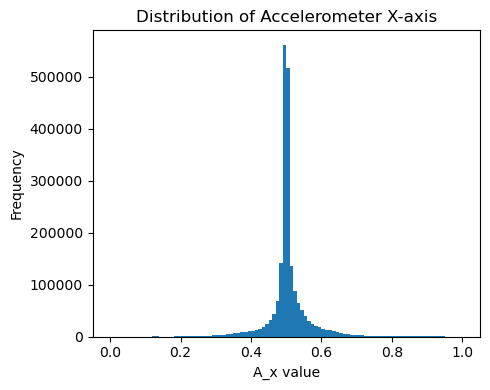

In [26]:
plt.figure(figsize=(5,4))
plt.hist(df["A_x"], bins=100)
plt.xlabel("A_x value")
plt.ylabel("Frequency")
plt.title("Distribution of Accelerometer X-axis")
plt.tight_layout()
plt.show()

#### **EDA – Class-wise Feature Comparison**

To gain a high-level understanding of how exercises differ, I compared the mean sensor values across classes.

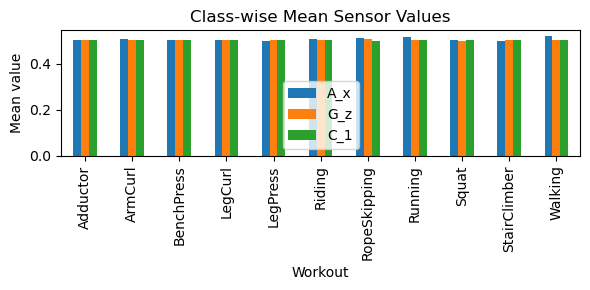

In [29]:
df.groupby("Workout")[["A_x","G_z","C_1"]].mean().plot(
    kind="bar", figsize=(6,3)
)
plt.ylabel("Mean value")
plt.title("Class-wise Mean Sensor Values")
plt.tight_layout()
plt.show()


The distribution of the A_x feature shows a strong central concentration with occasional extreme values, indicating the presence of short-term noise and rare spikes. This observation supports the use of outlier removal and smoothing during preprocessing.

In contrast, the class-wise mean values of representative sensor features are similar across exercise classes, suggesting that simple average-based features are insufficient for classification. This suggests that models capable of capturing more complex patterns and variability within the sensor signals.

# Part 2. Rank and Interpret the Algorithms by Basic numerical features


## **Selected Machine Learning Algorithms**

---

### Naive Bayes
- Naive Bayes is a representative classification algorithm based on Bayesian statistics and generative modeling.

### Logistic Regression

- Logistic regression is a model that assumes a linear relationship between the independent variables and the dependent variable.

### Decision Tree

- It is a rule-based algorithm that operates based on the uniformity of the data distribution.


### Support Vector Machine (SVM)

- SVM is a **binary linear classifier** that determines which category a given data point belongs to.  
- It draws two parallel lines through support vectors to define the decision boundary.  
- Unlike logistic regression, SVM’s cost function **considers the margin** — the distance between the boundary and the nearest data points.  
- **Slack variable (ξ)** is used in *Soft Margin SVM* to allow some misclassified samples outside the margin.  
- Larger ξ means more tolerance for margin violations.  


### K-Nearest Neighbors (K-NN)

- A very simple, non-parametric algorithm.
- It classifies a sample based on the majority label among its k nearest neighbors in feature space.
- The Euclidean distance is commonly used to measure closeness.
- Since no explicit cost function or training process is involved, K-NN is computationally heavy during prediction.
- The value of k is usually odd to avoid ties.

### Random Forest

- An ensemble model that combines multiple Decision Trees.
- Each tree is trained on random subsets of features and samples — helping reduce overfitting and increase diversity.
- The final prediction is made through a majority vote among all trees.
- Works well with both numerical and categorical data types.

### Ensemble
- It is an ensemble algorithm that combines different (or identical) machine learning algorithms.

### XGBoost
- XGBoost is an algorithm that further enhances the functionality of Gradient Boosting Machines (GBM).


# Common Set up
### Ready the Preprocessing Data and Start

In [30]:
# Basic libraries
import numpy as np
import pandas as pd

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Use the preprocessed dataframe (already smoothed & normalised)
df = feat_smooth.copy()

# Sensor features used in this project
features = ["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]
target = "Workout"

# Select X and y
X = df[features].values
y = df[target].values

# Explicit label mapping based on the problem definition
workout_mapping = {
    "Adductor": 0,
    "ArmCurl": 1,
    "BenchPress": 2,
    "LegCurl": 3,
    "LegPress": 4,
    "Riding": 5,
    "RopeSkipping": 6,
    "Running": 7,
    "Squat": 8,
    "StairClimber": 9,
    "Walking": 10
}

# Apply manual label encoding
y_encoded = df["Workout"].map(workout_mapping).values

# Train / Test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Classes:", list(le.classes_))

Train shape: (1518922, 7)
Test shape : (379731, 7)
Classes: [np.str_('Adductor'), np.str_('ArmCurl'), np.str_('BenchPress'), np.str_('LegCurl'), np.str_('LegPress'), np.str_('Riding'), np.str_('RopeSkipping'), np.str_('Running'), np.str_('Squat'), np.str_('StairClimber'), np.str_('Walking')]


## -1) **Naive Bayes(Gaussian NB)**- Baseline Model 1

In [31]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes assumes features follow a Gaussian distribution
# Simple baseline model, fast to train
nb_clf = GaussianNB()

# Train model
nb_clf.fit(X_train, y_train)

# Prediction
y_pred = nb_clf.predict(X_test)

# Evaluation
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Naive Bayes Accuracy: 0.36436582738833545

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.35      0.44      0.39     25989
     ArmCurl       0.20      0.11      0.14     28623
  BenchPress       0.23      0.81      0.36     25242
     LegCurl       0.12      0.08      0.10     24851
    LegPress       0.39      0.29      0.33     29881
      Riding       0.38      0.26      0.31     47468
RopeSkipping       0.69      0.52      0.59      9912
     Running       0.63      0.61      0.62     39652
       Squat       0.32      0.23      0.27     45654
StairClimber       0.36      0.32      0.34     50776
     Walking       0.52      0.46      0.49     51683

    accuracy                           0.36    379731
   macro avg       0.38      0.38      0.36    379731
weighted avg       0.38      0.36      0.36    379731



## 1) Naive Bayes Report Analysis
Next, I interpret the overall performance of the Naive Bayes classifier.

The model achieved an Accuracy of 0.364, a Macro F1-score of 0.36, and a Weighted F1-score of 0.36.
Given that the task involves 11 distinct classes, and that the sensor features are continuous-valued and exhibit strong inter-feature correlations, the relatively low performance of Naive Bayes is expected. This is because Naive Bayes relies on the following strong assumption: All features are conditionally independent given the class label.

Such an assumption is violated in wearable sensor data, where accelerometer and gyroscope signals are highly correlated across axes and time. Despite its limited performance, Naive Bayes serves as a useful baseline model, against which the performance of more complex classification algorithms can be compared.

An analysis of class-wise performance patterns further reveals that Naive Bayes performs relatively better for activities such as Running and BenchPress, which involve large-amplitude, repetitive, and highly structured movements, making them easier to distinguish even under the independence assumption.

## - 2) **Logistic Regression** - Baseline Model 2

In [32]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression for multi-class classification
# max_iter increased because dataset is large
lr_clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    n_jobs=-1
)

# Train
lr_clf.fit(X_train, y_train)

# Predict
y_pred = lr_clf.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Logistic Regression Accuracy: 0.1884017896879633

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.00      0.00      0.00     25989
     ArmCurl       0.00      0.00      0.00     28623
  BenchPress       0.00      0.00      0.00     25242
     LegCurl       0.00      0.00      0.00     24851
    LegPress       0.00      0.00      0.00     29881
      Riding       0.17      0.06      0.09     47468
RopeSkipping       0.91      0.04      0.07      9912
     Running       0.32      0.17      0.22     39652
       Squat       0.20      0.04      0.07     45654
StairClimber       0.15      0.72      0.25     50776
     Walking       0.26      0.44      0.33     51683

    accuracy                           0.19    379731
   macro avg       0.18      0.13      0.09    379731
weighted avg       0.16      0.19      0.12    379731



C:\Users\sogon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sogon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sogon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Next, I interpret the results of Logistic Regression.
The overall performance is as follows: Accuracy = 0.188, Macro F1 = 0.09, and Weighted F1 = 0.12.
In this 11-class classification problem, the model struggled to separate most classes.

The performance is much worse than that of Naive Bayes, showing that Logistic Regression is a performed poorly in this setting.

Classes such as Adductor, ArmCurl, BenchPress, LegCurl, and LegPress show zero precision and zero recall, meaning that the model did not correctly predict these classes even once.
Instead, predictions are mostly concentrated on StairClimber and Walking, indicating that Logistic Regression adopted a strategy of safely predicting only a small number of classes.

Next, I analyze why Logistic Regression produced such poor results.

First, this can be explained by the limitations of linear models.
When the relationship between X and y is non-linear, Logistic Regression cannot capture it well, leading to poor performance.
In this problem, the data consists of sensor signals, subtle differences between exercises, strong non-linearity, and heavy class overlap, making linear separability nearly impossible.

In addition, Logistic Regression uses multinomial logistic regression by default in multiclass settings, where a softmax function is applied at the output layer.
This can be problematic because softmax tends to push predictions toward a single class with the highest probability.
Under class imbalance, this often leads to prediction collapse toward the easiest or majority classes, resulting in biased predictions toward specific activities.

Overall, Logistic Regression lacks sufficient flexibility for complex problems.
When data patterns are complex and not linearly separable, Logistic Regression cannot adapt effectively, and its performance degrades significantly.

## - 3) **Support Vector Machine** - Baseline Model 3

In [33]:
from sklearn.svm import LinearSVC

# LinearSVC is used because RBF SVM is too slow for large data

svm_clf = LinearSVC(
    C=1.0,        # soft-margin parameter
    max_iter=5000
)


# Train
svm_clf.fit(X_train, y_train)

# Predict
y_pred = svm_clf.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


SVM Accuracy: 0.18601062330965867

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.00      0.00      0.00     25989
     ArmCurl       0.00      0.00      0.00     28623
  BenchPress       0.00      0.00      0.00     25242
     LegCurl       0.00      0.00      0.00     24851
    LegPress       0.00      0.00      0.00     29881
      Riding       0.18      0.04      0.07     47468
RopeSkipping       1.00      0.00      0.00      9912
     Running       0.29      0.15      0.20     39652
       Squat       0.20      0.03      0.05     45654
StairClimber       0.15      0.70      0.25     50776
     Walking       0.25      0.50      0.33     51683

    accuracy                           0.19    379731
   macro avg       0.19      0.13      0.08    379731
weighted avg       0.16      0.19      0.11    379731



C:\Users\sogon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sogon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sogon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In this experiment, the SVM model achieved a low classification accuracy of approximately 18%, showing overall very poor performance.
For multiple exercise classes, both precision and recall were zero, indicating that the model was almost unable to predict those activities.

In particular, exercises such as Adductor, ArmCurl, and BenchPress were not distinguished at all by the model.
In contrast, predictions were heavily concentrated on a small number of exercises, mainly StairClimber and Walking.

These results can be attributed to the fact that SVM operates based on linear decision boundaries.
The dataset consists of values obtained from accelerometer and gyroscope sensors, where strong correlations exist between sensors and the overall patterns are highly complex.
In addition, many exercise activities share similar movement patterns, resulting in unclear class boundaries.
Such non-linear and overlapping data structures are difficult for linear models to separate effectively.

Moreover, in multiclass classification, SVM performs classification using a One-vs-Rest strategy.
During this process, predictions can become biased toward a small number of classes that are easier to separate.
As a result, the model fails to predict all exercise classes evenly and instead focuses on specific activities.

Therefore, the experimental results suggest that the poor performance is not due to data preprocessing issues, but rather due to the limited representational capacity of the model with respect to the characteristics of the problem.

In conclusion, SVM is not an appropriate model for this sensor-based exercise classification task, and the results confirm the need for non-linear models capable of learning more complex patterns, such as Decision Trees, ensemble methods, or kNN.

## - 4) Decision Tree Visualization

This code creates and trains a Decision Tree classification model.
First, a Decision Tree classifier is initialized with a fixed random seed.
Then, the model learns classification rules from the training data (X_train, y_train).

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

#Generate DecisionTree Classifier
dt_clf=DecisionTreeClassifier(random_state=156)

#Train DecisionTreeClassifier
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=156)

First, the export_graphviz function is used to save the trained Decision Tree model as a DOT file (tree.dot).
Then, Graphviz is used to load this file and render the tree structure as a visual diagram.
This allows intuitive inspection of how the model performs classification and which criteria it uses for decision-making.

In [35]:
from sklearn.tree import export_graphviz

export_graphviz(
    dt_clf,
    out_file="tree.dot",
    feature_names=features,
    class_names=le.classes_,
    impurity=True,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3
)


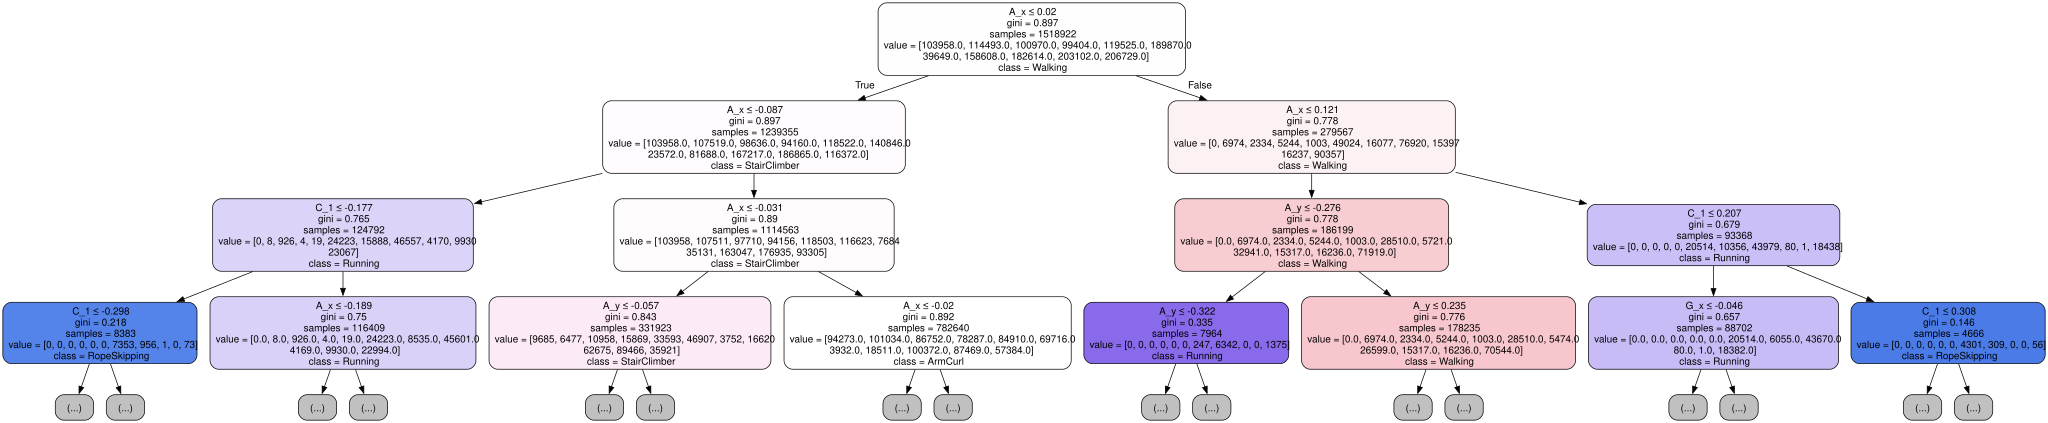

In [36]:
import graphviz

with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

## Decision Tree Visualization Analysis

From the Decision Tree visualization, it can be observed that the model relies most heavily on the A_x acceleration feature during the classification process.
At the root node, the data is broadly split into two groups based on the A_x value, indicating that left–right or forward–backward movements play an important role in exercise classification.

At the upper levels of the tree, the gini values are very high, showing that multiple exercise classes are mixed together.
This suggests that a single sensor feature alone is insufficient to clearly distinguish between different exercises.

As the tree descends to lower nodes, additional features such as C_1 and A_y are used, and certain exercises (e.g., Running and RopeSkipping) tend to be separated more clearly.
In particular, RopeSkipping shows a low gini value, indicating that it has distinctive characteristics that allow it to be well separated from other exercises.

In contrast, exercises such as Walking, StairClimber, and ArmCurl are distributed across multiple nodes, leading to frequent confusion.
This implies that these activities share similar sensor patterns.

Overall, the Decision Tree is able to learn exercise patterns to some extent using key sensor features.
However, the results indicate that the model has limitations in fully separating complex and overlapping class boundaries.

In [37]:
dt_clf.feature_importances_

array([0.15686316, 0.14135411, 0.11843485, 0.13252258, 0.14306516,
       0.16391856, 0.14384158])

In [38]:
features

['A_x', 'A_y', 'A_z', 'G_x', 'G_y', 'G_z', 'C_1']

Feature importances:
 [0.157 0.141 0.118 0.133 0.143 0.164 0.144]
A_x: 0.157
A_y: 0.141
A_z: 0.118
G_x: 0.133
G_y: 0.143
G_z: 0.164
C_1: 0.144


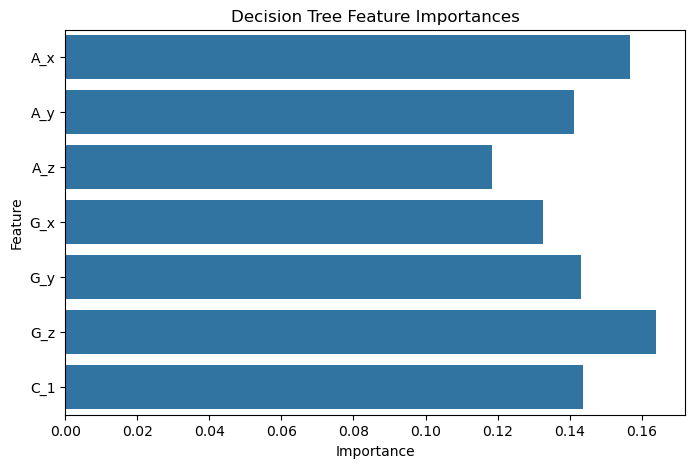

In [39]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Feature name list
features = ["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]

# Feature importances 
print("Feature importances:\n",
      np.round(dt_clf.feature_importances_, 3))

# Feature importance mapping
for name, value in zip(features, dt_clf.feature_importances_):
    print(f"{name}: {value:.3f}")

# 3️Feature importance visualisation
plt.figure(figsize=(8, 5))
sns.barplot(
    x=dt_clf.feature_importances_,
    y=features,
    orient="h"
)
plt.title("Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Decision Tree Feature Importances Analysis

The decision tree feature importance analysis shows that all sensor features contribute relatively evenly to exercise classification. Among them, G_z and A_x have the highest importance, indicating that vertical rotational motion and acceleration along the x-axis play a slightly more influential role. The HBC feature (C_1) also demonstrates comparable importance, suggesting that body capacitance provides meaningful complementary information alongside IMU sensors.

## -4) Decision Tree

In [42]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree model
dt_clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=16,
    min_samples_leaf=6
)

# Train
dt_clf.fit(X_train, y_train)

# Predict
y_pred = dt_clf.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Decision Tree Accuracy: 0.55279131806463

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.58      0.47      0.52     25989
     ArmCurl       0.53      0.39      0.45     28623
  BenchPress       0.43      0.55      0.48     25242
     LegCurl       0.39      0.42      0.41     24851
    LegPress       0.52      0.46      0.49     29881
      Riding       0.57      0.61      0.59     47468
RopeSkipping       0.78      0.53      0.63      9912
     Running       0.79      0.67      0.73     39652
       Squat       0.51      0.47      0.49     45654
StairClimber       0.47      0.62      0.53     50776
     Walking       0.67      0.67      0.67     51683

    accuracy                           0.55    379731
   macro avg       0.57      0.53      0.54    379731
weighted avg       0.56      0.55      0.55    379731



## 4) Decision Tree Analysis

The Decision Tree model achieved an overall accuracy of 55.3%, which can be considered limited given the 11-class multi-class classification setting. The Macro F1-score and Weighted F1-score were 0.54 and 0.55, respectively, indicating the presence of performance variability across classes.

Class-wise performance analysis shows that exercises involving large, repetitive full-body movements like Running, Walking, RopeSkipping, and Riding—exhibit relatively higher precision and recall. In particular, the Running class achieved an F1-score of 0.73, while Walking reached 0.67, demonstrating more stable classification performance compared to other classes. This can be attributed to the relatively distinct acceleration and gyroscope signal patterns associated with these activities.

In contrast, exercises primarily involving localized muscle activation, including Adductor, ArmCurl, LegCurl, and LegPress, generally showed low recall and F1-scores. These movements often have limited motion ranges or share similar sensor patterns with other exercises, resulting in less clearly separable class boundaries in the feature space.

Additionally, the StairClimber class demonstrated a relatively high recall (0.62) but low precision, suggesting a tendency for this activity to be confused with other similar exercises. This observation highlights how class overlap and sensor noise directly impact classification performance in sensor-based exercise recognition tasks.

Overall, while the Decision Tree model achieved meaningful performance for certain well-defined exercise classes, it struggled to generalize across the full complexity of the multi-class sensor dataset. These results suggest that modeling approaches capable of capturing more complex nonlinear relationships, or ensemble-based methods, may be more suitable for this task.

## -5) KNN (K-Nearest Neighbor)

In [43]:
from sklearn.neighbors import KNeighborsClassifier

# KNN is a non-parametric model so, classification is based on majority vote of nearest neighbours

knn_clf = KNeighborsClassifier(
    n_neighbors=11,   # odd
    metric="euclidean"
)

# Train
knn_clf.fit(X_train, y_train)

# Predict
y_pred = knn_clf.predict(X_test)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

KNN Accuracy: 0.6635671040815735

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.59      0.66      0.62     25989
     ArmCurl       0.54      0.62      0.58     28623
  BenchPress       0.50      0.53      0.51     25242
     LegCurl       0.50      0.52      0.51     24851
    LegPress       0.62      0.62      0.62     29881
      Riding       0.69      0.73      0.71     47468
RopeSkipping       0.91      0.60      0.73      9912
     Running       0.88      0.74      0.80     39652
       Squat       0.66      0.60      0.62     45654
StairClimber       0.65      0.68      0.67     50776
     Walking       0.80      0.78      0.79     51683

    accuracy                           0.66    379731
   macro avg       0.67      0.64      0.65    379731
weighted avg       0.67      0.66      0.67    379731



## KNN Analysis

The KNN classifier achieved an overall accuracy of 66.4%, which is higher than the single Decision Tree model evaluated on the same dataset (about 55% accuracy). The Macro F1-score was 0.65, and the Weighted F1-score was 0.67, showing that the model performed at a similar level across most classes.

Looking at the F1-score for each class, Running (0.80), Walking (0.79), RopeSkipping (0.73), and Riding (0.71) showed higher performance. In contrast, BenchPress (0.51), LegCurl (0.51), and ArmCurl (0.58) showed lower F1-scores. This indicates that classification performance varies across classes.

For the RopeSkipping class, precision was very high (0.91), but recall was lower (0.60). This means the model made fewer predictions for this class, but most of those predictions were correct. For the StairClimber class, recall (0.68) was slightly higher than precision (0.65), showing a different balance between correct detections and false positives.

Overall, the KNN model performed well for some classes but less well for others. These results show that classification difficulty is not the same for all exercise types, and a single model does not achieve the same performance across all classes.

## 6) Ensemble Learning – Random Forest

Before examining the Random Forest technique, we first introduce the concept of ensemble learning. Ensemble-based classification refers to a method that generates multiple classifiers and combines their predictions to produce a more accurate final prediction.

Similar to how a committee of experts gathers diverse opinions before reaching a conclusion on a complex problem, ensemble learning aims to achieve more reliable predictions than a single classifier by aggregating the outputs of multiple models.

Ensemble methods are generally categorized into voting, bagging, and boosting, with additional techniques such as stacking.

A representative example of a bagging-based method is the Random Forest algorithm, while boosting-based methods include AdaBoost, Gradient Boosting, XGBoost, and LightGBM. For classification and regression tasks on tabular data, boosting-based ensemble methods, particularly Gradient Boosting Machines (GBM), are widely known to demonstrate strong predictive performance.

In a broader sense, ensemble learning can also refer to approaches that combine different types of models.

## Characteristics of Ensemble Learning

The weaknesses of a single model can be compensated for by combining multiple models.

An ensemble does not necessarily require only high-performing individual models; combining different types of models, even those with lower individual performance, can sometimes improve overall performance.

Random Forest and advanced boosting algorithms are all based on decision tree algorithms as their base learners.

One of the major drawbacks of decision trees, overfitting, is mitigated by combining dozens to thousands of trees, while their strength—intuitive decision rules—is preserved.

## - 6) Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=24,
    min_samples_split=8,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1   
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=24, min_samples_split=8, n_estimators=80,
                       n_jobs=-1, random_state=42)

In [50]:
# Predict
y_pred = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Random Forest Accuracy: 0.6692816757125439

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.68      0.59      0.63     25989
     ArmCurl       0.60      0.52      0.56     28623
  BenchPress       0.51      0.60      0.55     25242
     LegCurl       0.52      0.54      0.53     24851
    LegPress       0.65      0.59      0.62     29881
      Riding       0.72      0.72      0.72     47468
RopeSkipping       0.92      0.59      0.72      9912
     Running       0.84      0.77      0.81     39652
       Squat       0.64      0.62      0.63     45654
StairClimber       0.62      0.75      0.67     50776
     Walking       0.76      0.80      0.78     51683

    accuracy                           0.67    379731
   macro avg       0.68      0.64      0.66    379731
weighted avg       0.68      0.67      0.67    379731



## Random Forest Analysis
The Random Forest classifier achieved an accuracy of 0.669 on the test dataset, showing an overall improvement in classification performance compared to the Decision Tree model. This improvement can be attributed to the ensemble of multiple decision trees, which helps reduce overfitting and enables more stable learning of complex sensor patterns. The macro-averaged metrics also indicate relatively balanced performance across classes, confirming that the overall classification capability was enhanced without excessive bias toward specific classes.

Classes with strong classification performance include Running, Walking, StairClimber, and Riding, which involve large-scale full-body movements and therefore exhibit higher precision and recall.

In contrast, exercises characterized by more localized movements, such as ArmCurl and LegCurl, showed limitations in class separability even with the Random Forest model.

For RopeSkipping, a distinctive pattern was observed, with a high precision of 0.92 but a relatively low recall of 0.59. This indicates a conservative prediction behavior, where the model predicts RopeSkipping only when it is highly confident.

## - 6-2) Random Forest Visualisation
Since the input feature set consists of only seven features, feature importance analysis does not yield additional benefits in terms of feature selection.
However, Random Forest–based feature importance was employed to quantitatively evaluate the relative importance of each IMU axis and the HBC signal in exercise classification.
This approach allows for an interpretative comparison of the contributions of IMU and HBC signals.

Random Forest Accuracy (light version): 0.5945


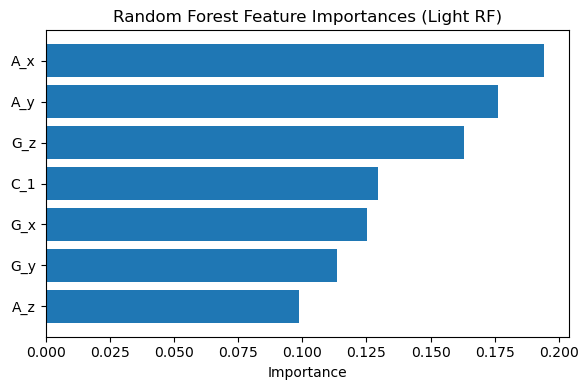

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Data Sampling
n = min(150_000, len(X_train))
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), size=n, replace=False)

X_small = X_train.iloc[idx]
y_small = y_train.iloc[idx] if hasattr(y_train, "iloc") else y_train[idx]

rf = RandomForestClassifier(
    n_estimators=40,
    max_depth=16,
    min_samples_leaf=6,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_small, y_small)

# Accuracy Check
pred = rf.predict(X_test)
print(f"Random Forest Accuracy (light version): {accuracy_score(y_test, pred):.4f}")

# Feature importance
feature_names = list(X_train.columns)

ftr_importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Visualisation
plt.figure(figsize=(6, 4))
plt.barh(ftr_importances.index, ftr_importances.values)
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importances (Light RF)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Random Forest Feature Importances Analysis
The Random Forest feature importance results show that the x-axis (A_x) and y-axis (A_y) of the accelerometer are the most important features. This means that forward and side-to-side acceleration changes play a key role in exercise classification.

For the gyroscope, the G_z axis has relatively high importance, suggesting that rotational motion is an important factor for distinguishing different exercises.

The HBC signal acts as a supporting feature and helps complement the IMU signals.

# 7) XGBoost Introduction (eXtreme Gradient Boosting)

**XGBoost** stands for **eXtreme Gradient Boosting** and is a widely used machine learning algorithm known for its outstanding predictive performance.  
Compared to traditional **GBM (Gradient Boosting Machine)**, XGBoost offers faster training speed and incorporates various performance-enhancing features.

## Key Advantages

- High predictive accuracy  
- Faster execution speed compared to traditional GBM  
- Prevention of overfitting through **Regularization** and **Tree Pruning**  
- Various convenience features such as **Early Stopping**, built-in cross-validation, and automatic handling of missing values  

---

## Early Stopping in XGBoost

XGBoost provides an **Early Stopping** mechanism that allows the training process to stop before completing all predefined iterations if the **loss function (evaluation metric)** no longer improves.

This feature helps **reduce unnecessary training iterations**, thereby saving computational time.  
It is especially useful during the **hyperparameter tuning** phase.

However, if the number of iterations is set too low, training may stop prematurely, resulting in a model that has not fully converged and therefore does not achieve optimal predictive performance. Caution is required when configuring early stopping.

### Key Parameters for Early Stopping

- **early_stopping_rounds**  
  The maximum number of consecutive iterations allowed without improvement in the evaluation metric.

- **eval_metric**  
  The metric used to evaluate model performance during training.

- **eval_set**  
  A separate validation dataset used to evaluate model performance.  
  Typically, performance improvement is repeatedly assessed on this validation set during training.


In [54]:
#Check Library and Version
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import xgboost
from xgboost import XGBClassifier, plot_importance

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

print("xgboost version:", xgboost.__version__)

xgboost version: 3.1.2


In [55]:
#Data Preparation - Use feat_smooth

# Data Preparation - use feat_smooth (already preprocessed & smoothed)
features = ["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]

X = feat_smooth[features]
y = feat_smooth["Workout"]

# label encoding (string -> number)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Num classes:", len(le.classes_))
print("X shape:", X.shape)


Classes: ['Adductor' 'ArmCurl' 'BenchPress' 'LegCurl' 'LegPress' 'Riding'
 'RopeSkipping' 'Running' 'Squat' 'StairClimber' 'Walking']
Num classes: 11
X shape: (1898653, 7)


In [56]:
#Split Train/Test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train for fit:", X_tr.shape)
print("Validation    :", X_val.shape)

num_classes = len(np.unique(y_train))
print("num_classes:", num_classes)


Train: (1518922, 7)
Test : (379731, 7)
Train for fit: (1367029, 7)
Validation    : (151893, 7)
num_classes: 11


In [57]:
# Build XGBoost model (multiclass)

xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",

    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print(xgb_clf)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=11, ...)


In [58]:
# Train with early stopping

xgb_clf = XGBClassifier(
    n_estimators=2000,          
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],  
    verbose=50
)
print("Best iteration:", xgb_clf.best_iteration)



[0]	validation_0-mlogloss:2.33808
[50]	validation_0-mlogloss:1.50758
[100]	validation_0-mlogloss:1.33234
[150]	validation_0-mlogloss:1.25335
[200]	validation_0-mlogloss:1.20686
[250]	validation_0-mlogloss:1.17378
[300]	validation_0-mlogloss:1.14839
[350]	validation_0-mlogloss:1.12915
[400]	validation_0-mlogloss:1.11324
[450]	validation_0-mlogloss:1.10020
[500]	validation_0-mlogloss:1.08838
[550]	validation_0-mlogloss:1.07864
[600]	validation_0-mlogloss:1.06967
[650]	validation_0-mlogloss:1.06163
[700]	validation_0-mlogloss:1.05337
[750]	validation_0-mlogloss:1.04592
[800]	validation_0-mlogloss:1.03944
[850]	validation_0-mlogloss:1.03329
[900]	validation_0-mlogloss:1.02777
[950]	validation_0-mlogloss:1.02224
[1000]	validation_0-mlogloss:1.01697
[1050]	validation_0-mlogloss:1.01198
[1100]	validation_0-mlogloss:1.00754
[1150]	validation_0-mlogloss:1.00322
[1200]	validation_0-mlogloss:0.99916
[1250]	validation_0-mlogloss:0.99511
[1300]	validation_0-mlogloss:0.99141
[1350]	validation_0-mlog

In [59]:
# Test set Prediction and Evaluation
pred = xgb_clf.predict(X_test)

print("XGBoost Accuracy:", f"{accuracy_score(y_test, pred):.4f}")

print("\nClassification Report")
print(classification_report(
    y_test, pred,
    target_names=le.classes_
))


XGBoost Accuracy: 0.6481

Classification Report
              precision    recall  f1-score   support

    Adductor       0.64      0.60      0.62     25989
     ArmCurl       0.59      0.57      0.58     28623
  BenchPress       0.52      0.57      0.54     25242
     LegCurl       0.51      0.54      0.52     24851
    LegPress       0.60      0.59      0.60     29881
      Riding       0.67      0.68      0.68     47468
RopeSkipping       0.87      0.63      0.73      9912
     Running       0.85      0.75      0.79     39652
       Squat       0.62      0.57      0.59     45654
StairClimber       0.60      0.69      0.64     50776
     Walking       0.74      0.77      0.75     51683

    accuracy                           0.65    379731
   macro avg       0.66      0.63      0.64    379731
weighted avg       0.65      0.65      0.65    379731



### XGBoost Report Analysis
Overall, the XGBoost model demonstrated relatively weak performance, with an accuracy of approximately 0.65, a macro F1-score of 0.64, and a weighted F1-score of 0.65.
A noticeable drop in recall was observed for classes with fewer samples, such as RopeSkipping.
In contrast, Running and Walking were classified more reliably, whereas classes such as BenchPress, LegCurl, and Squat were more difficult to distinguish due to the similarity in lower-body joint movements, which leads to overlapping sensor patterns.

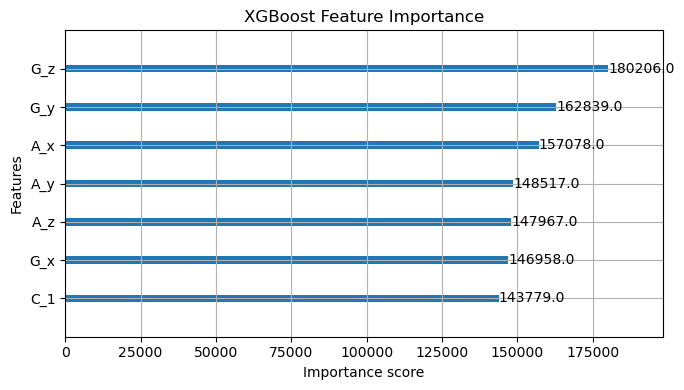

In [60]:
# Feature Importance Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
plot_importance(xgb_clf, ax=ax, max_num_features=7)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


### XGBoost Feature Importance Analysis

The feature importance distribution shows that the model does not rely excessively on any single feature, with importance values being relatively evenly distributed across features.
However, this also suggests the absence of a dominant feature with strong discriminative power.

## -8) Light GBM

Naive Bayes, Logistic Regression, and SVM were treated as baseline models with limited hyperparameter flexibility and were therefore trained and evaluated directly on the test set without a separate validation set.

LightGBM, due to its higher model complexity and increased risk of overfitting, employed an additional validation set for early stopping and hyperparameter selection.

Given the continuous and highly correlated nature of the time-series sensor data, the evaluation aims to provide an overall assessment of model behaviour and generalisation rather than a strictly controlled hyperparameter comparison.
Accordingly, different models are evaluated using strategies appropriate to their respective complexity, with the test set reserved exclusively for final performance assessment.

In [62]:
import lightgbm

print(lightgbm.__version__)

4.6.0


In [63]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from lightgbm import LGBMClassifier
from lightgbm import plot_importance, early_stopping, log_evaluation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, classification_report
)

import matplotlib.pyplot as plt


In [64]:
df_model = feat_smooth.copy()

sensor_features = ["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]
target_col = "Workout"

missing = [c for c in sensor_features + [target_col] if c not in df_model.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

X = df_model[sensor_features].copy()
y = df_model[target_col].copy()

# numeric safety (optional)
X = X.apply(pd.to_numeric, errors="coerce")
if X.isnull().any().any():
    print("Warning: NaNs detected in X.")
    print(X.isnull().sum())

print("X shape:", X.shape)
print("y unique classes:", y.nunique())
print("Features used:", list(X.columns))

X shape: (1898653, 7)
y unique classes: 11
Features used: ['A_x', 'A_y', 'A_z', 'G_x', 'G_y', 'G_z', 'C_1']


In [65]:
#Split (train/val/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=156, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156, stratify=y_train
)

print("Train:", X_tr.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1367029, 7) Val: (151893, 7) Test: (379731, 7)


In [66]:
# LightGBM 
num_classes = y.nunique() 

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,
    n_estimators=400,
    learning_rate=0.05,
    random_state=156,
    n_jobs=-1
)

lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],           
    eval_metric="multi_logloss",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=20)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 1367029, number of used features: 7
[LightGBM] [Info] Start training from score -2.681771
[LightGBM] [Info] Start training from score -2.585239
[LightGBM] [Info] Start training from score -2.710932
[LightGBM] [Info] Start training from score -2.726559
[LightGBM] [Info] Start training from score -2.542235
[LightGBM] [Info] Start training from score -2.079416
[LightGBM] [Info] Start training from score -3.645693
[LightGBM] [Info] Start training from score -2.259321
[LightGBM] [Info] Start training from score -2.118385
[LightGBM] [Info] Start training from score -2.012046
[LightGBM] [Info] Start training from score -1.994347
Training until validation scores don't improve for 50 rounds
[20]	valid_0's multi_logloss: 1.50578
[40]	valid_0's mu

LGBMClassifier(learning_rate=0.05, n_estimators=400, n_jobs=-1, num_class=11,
               objective='multiclass', random_state=156)

In [67]:
y_pred = lgbm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.620344401694884
Macro F1: 0.6150425720324897
Weighted F1: 0.6215985673143217

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.63      0.57      0.60     25989
     ArmCurl       0.58      0.55      0.56     28623
  BenchPress       0.51      0.57      0.54     25242
     LegCurl       0.48      0.53      0.50     24851
    LegPress       0.57      0.56      0.57     29881
      Riding       0.66      0.62      0.64     47468
RopeSkipping       0.85      0.59      0.70      9912
     Running       0.82      0.72      0.77     39652
       Squat       0.59      0.53      0.56     45654
StairClimber       0.56      0.67      0.61     50776
     Walking       0.70      0.74      0.72     51683

    accuracy                           0.62    379731
   macro avg       0.63      0.61      0.62    379731
weighted avg       0.63      0.62      0.62    379731



### 8) LightGBM Analysis
For the LightGBM model, the achieved performance was an accuracy of 0.62, a macro F1-score of 0.62, and a weighted F1-score of 0.62.
The similarity across these three metrics is notable, as it indicates relatively balanced classification performance across classes.
Considering the multi-class setting with 11 activity classes and the continuous nature of the time-series sensor data, this result demonstrates a stable and reliable level of performance.

A class-wise analysis shows that activities with clear periodic patterns, such as Riding, Running, and Walking, achieve higher classification performance.
Although LegCurl, LegPress, and Squat are comparatively more challenging classes.
This can be attributed to the similarity in joint movements among lower-body exercises, which leads to overlapping acceleration and angular velocity patterns in the sensor data.

### 8) LightGBM Feature Importance Visualisation

Feature importance (sorted by GAIN):


,feature,importance_gain,importance_split
6,C_1,7.623959e+08,14257
2,A_z,4.280221e+08,15630
4,G_y,3.297433e+08,17936
1,A_y,3.177449e+08,16377
3,G_x,1.728759e+08,14589
0,A_x,1.367709e+08,17399
5,G_z,5.383541e+07,20962


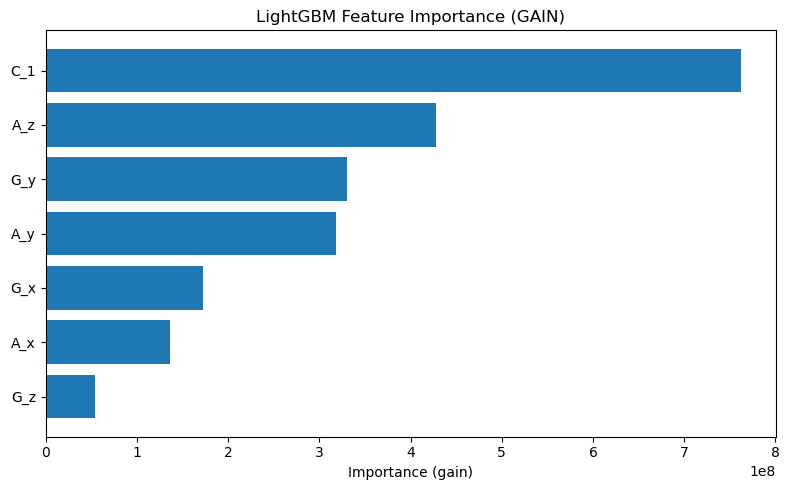

In [68]:
# To visualise feature importance to interpret the model
import pandas as pd
import matplotlib.pyplot as plt

feature_names = lgbm.booster_.feature_name()

fi = pd.DataFrame({
    "feature": feature_names,
    "importance_gain": lgbm.booster_.feature_importance(importance_type="gain"),
    "importance_split": lgbm.booster_.feature_importance(importance_type="split")
}).sort_values("importance_gain", ascending=False)

print("Feature importance (sorted by GAIN):")
display(fi)

fi_sorted = fi.sort_values("importance_gain")

plt.figure(figsize=(8, 5))
plt.title("LightGBM Feature Importance (GAIN)")
plt.barh(fi_sorted["feature"], fi_sorted["importance_gain"])
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()


## 8) LightGBM Feature Importance Analysis
Based on the gain-based feature importance analysis of the LightGBM model, A_z and C_1 exhibit the highest importance and contribute most significantly to the classification performance.
In addition, acceleration axes such as G_y and A_y also rank highly, suggesting that acceleration signals serve as key discriminative cues for activities involving periodic movements.
In contrast, G_z shows a relatively high split count but low gain, indicating that while it is frequently used in decision splits, its contribution to loss reduction at each split is comparatively limited, and thus it functions as a supplementary feature rather than a dominant one.

## Total Result Anaylsis (1. Naive Bayes ~ 8. LightGBM Analysis)
Overall, Random Forest achieved the best performance across all evaluation metrics, including accuracy, macro F1-score, and weighted F1-score, with KNN showing comparable results. In contrast, linear models such as Logistic Regression and SVM performed poorly, indicating their limitations in capturing the non-linear patterns present in continuous time-series sensor data.

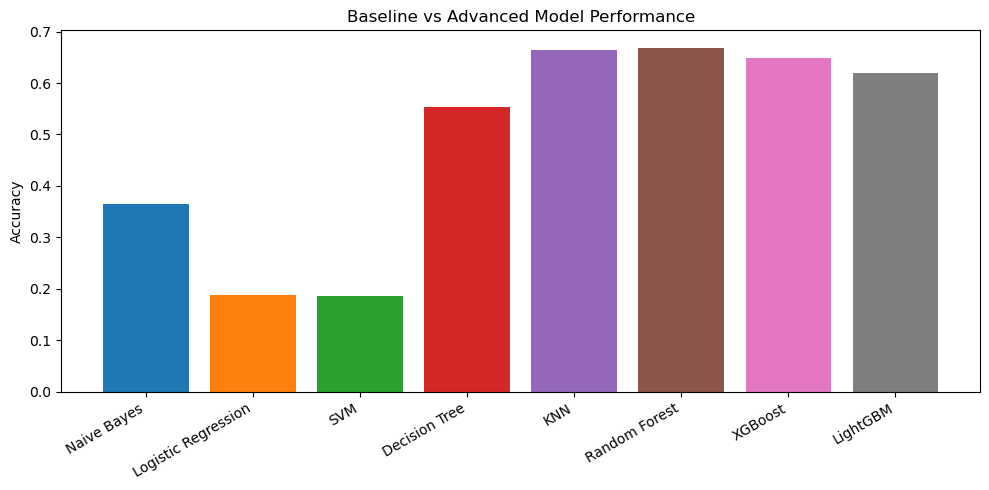

In [69]:
import matplotlib.pyplot as plt

models = [
    "Naive Bayes", "Logistic Regression", "SVM",
    "Decision Tree", "KNN", "Random Forest",
    "XGBoost", "LightGBM"
]

accuracy = [
    0.364, 0.188, 0.186,
    0.553, 0.664, 0.669,
    0.648, 0.620
]

# x location
x_position = list(range(len(models)))

plt.figure(figsize=(10, 5))

for i in range(len(models)):
    plt.bar(x_position[i], accuracy[i])

plt.xticks(x_position, models, rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Baseline vs Advanced Model Performance")
plt.tight_layout()
plt.show()


# **Part3: Find the optimised algorithm with context**

In this part, experiments are conducted based on the preprocessed contextual features, including **Subject, Session, and Position**, in addition to the sensor data.
Furthermore, a new optimised algorithm is constructed using an ensemble approach, which combines the predictions of multiple high-performing models to enhance robustness and overall classification performance.
Contextual features such as Subject, Session, and Position are treated as auxiliary metadata available at inference time, rather than labels or post-hoc information. 
Their inclusion aims to evaluate how contextual cues can complement sensor-based classification in realistic deployment scenarios.

In [70]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

df_model = feat_smooth.copy()

sensor_features = ["A_x", "A_y", "A_z", "G_x", "G_y", "G_z", "C_1"]
target_col = "Workout"

context_candidates = ["Subject", "Session", "Position"]
context_features = [c for c in context_candidates if c in df_model.columns]

features = sensor_features + context_features
print("Context features used:", context_features)
print("Total features:", features)

# X, y
X = df_model[features].copy()
y = df_model[target_col].copy()

for c in context_features:
    X[c] = X[c].astype(str)

le = LabelEncoder()
y_enc = le.fit_transform(y)


Context features used: ['Subject', 'Session', 'Position']
Total features: ['A_x', 'A_y', 'A_z', 'G_x', 'G_y', 'G_z', 'C_1', 'Subject', 'Session', 'Position']


In [71]:
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))
print("num_classes:", num_classes)

Classes: ['Adductor', 'ArmCurl', 'BenchPress', 'LegCurl', 'LegPress', 'Riding', 'RopeSkipping', 'Running', 'Squat', 'StairClimber', 'Walking']
num_classes: 11


In [72]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), context_features),
        ("num", "passthrough", sensor_features),
    ],
    remainder="drop"
)


In [73]:
#Split the data(train/test/validation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=156, stratify=y_enc
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156, stratify=y_train
)

print("Train:", X_tr.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1367029, 10) Val: (151893, 10) Test: (379731, 10)


## Weighted Softed Voting Ensemble

To construct an optimised ensemble model, a soft voting strategy was employed to combine the predictions of XGBoost, KNN, and Random Forest classifiers.
Soft voting aggregates the predicted class probabilities from each base model using a weighted sum, allowing models with stronger performance to exert greater influence on the final decision.

The ensemble weights were optimised using a validation set. A grid search over a small range of integer weights was conducted, and the combination that maximised the macro F1-score on the validation set was selected.
This approach ensures balanced performance across all activity classes while avoiding direct optimisation on the test set.

After determining the optimal weights, the ensemble model was retrained using the combined training and validation sets. Final performance was then evaluated on a held-out test set to provide an unbiased assessment of generalisation performance.

In [79]:
#KNN
knn_model = Pipeline([
    ("prep", preprocess),
    ("scaler", StandardScaler(with_mean=False)),
    ("knn", KNeighborsClassifier(
        n_neighbors=15,
        n_jobs=1
    ))
])

#KNN Training
knn_model.fit(X_tr, y_tr)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Subject', 'Session',
                                                   'Position']),
                                                 ('num', 'passthrough',
                                                  ['A_x', 'A_y', 'A_z', 'G_x',
                                                   'G_y', 'G_z', 'C_1'])])),
                ('scaler', StandardScaler(with_mean=False)),
                ('knn', KNeighborsClassifier(n_jobs=1, n_neighbors=15))])

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=156
    ))
])

rf_model.fit(X_tr, y_tr)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Subject', 'Session',
                                                   'Position']),
                                                 ('num', 'passthrough',
                                                  ['A_x', 'A_y', 'A_z', 'G_x',
                                                   'G_y', 'G_z', 'C_1'])])),
                ('rf',
                 RandomForestClassifier(max_depth=20, min_samples_leaf=5,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=156))])

In [81]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("prep", preprocess),
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=-1,
        random_state=156
    ))
])

xgb_model.fit(X_tr, y_tr)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Subject', 'Session',
                                                   'Position']),
                                                 ('num', 'passthrough',
                                                  ['A_x', 'A_y', 'A_z', 'G_x',
                                                   'G_y', 'G_z', 'C_1'])])),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               ea...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1, num_class=11, ...))])

In [82]:
#Validation Calculation
proba_xgb = xgb_model.predict_proba(X_val)
proba_knn = knn_model.predict_proba(X_val)
proba_rf  = rf_model.predict_proba(X_val)

#Label indexing
classes_ = np.arange(num_classes)

  File "C:\Users\sogon\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\sogon\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sogon\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sogon\anaconda3\Lib\subprocess.

In [83]:
def weighted_soft_voting(proba_xgb, proba_knn, proba_rf, weights):
    w_xgb, w_knn, w_rf = weights
    w_sum = w_xgb + w_knn + w_rf

    proba_ens = (
        w_xgb * proba_xgb +
        w_knn * proba_knn +
        w_rf  * proba_rf
    ) / w_sum

    pred = np.argmax(proba_ens, axis=1)
    return pred, proba_ens


In [84]:
best_score = -1
best_w = None

for w_xgb in [1, 2, 3]:
    for w_knn in [1, 2, 3]:
        for w_rf in [1, 2, 3]:
            weights = (w_xgb, w_knn, w_rf)

            pred_val, _ = weighted_soft_voting(
                proba_xgb, proba_knn, proba_rf, weights
            )

            score = f1_score(y_val, pred_val, average="macro")

            if score > best_score:
                best_score = score
                best_w = weights

print("Best weights (XGB, KNN, RF):", best_w)
print("Best validation Macro F1:", best_score)

Best weights (XGB, KNN, RF): (1, 3, 3)
Best validation Macro F1: 0.8592936451377956


In [86]:
#Test probabilities 
proba_xgb_test = xgb_model.predict_proba(X_test)
proba_knn_test = knn_model.predict_proba(X_test)
proba_rf_test  = rf_model.predict_proba(X_test)

In [87]:
pred_test, proba_ens_test = weighted_soft_voting(
    proba_xgb_test,
    proba_knn_test,
    proba_rf_test,
    best_w
)

print("Ensemble Test Accuracy:", accuracy_score(y_test, pred_test))
print("Ensemble Test Macro F1:", f1_score(y_test, pred_test, average="macro"))
print("Ensemble Test Weighted F1:", f1_score(y_test, pred_test, average="weighted"))
print(classification_report(y_test, pred_test))


Ensemble Test Accuracy: 0.8674851407970379
Ensemble Test Macro F1: 0.8595188189644163
Ensemble Test Weighted F1: 0.8674865145287795
              precision    recall  f1-score   support

           0       0.85      0.89      0.87     25989
           1       0.83      0.88      0.85     28623
           2       0.81      0.83      0.82     25242
           3       0.81      0.83      0.82     24851
           4       0.84      0.85      0.84     29881
           5       0.88      0.91      0.89     47468
           6       0.99      0.72      0.83      9912
           7       0.95      0.83      0.89     39652
           8       0.87      0.85      0.86     45654
           9       0.86      0.89      0.88     50776
          10       0.89      0.91      0.90     51683

    accuracy                           0.87    379731
   macro avg       0.87      0.85      0.86    379731
weighted avg       0.87      0.87      0.87    379731



## Sensor-only Ensemble Model
To investigate whether the large performance improvement is primarily caused by the ensemble strategy itself or by the inclusion of contextual features, an additional ensemble experiment was conducted using sensor features only.

This sensor-only ensemble combines KNN, Random Forest, and XGBoost using weighted soft voting, with weights optimised on a validation set. The resulting performance is then compared against both single-model baselines and the context-enhanced ensemble model.

This intermediate experiment allows the effects of model combination and feature augmentation to be disentangled, providing a more transparent interpretation of the final performance gain.

In [88]:
# 1) Prepare X, y
X = df_model[sensor_features].copy()
y = df_model[target_col].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)

num_classes = len(le.classes_)
print("Classes:", list(le.classes_))
print("num_classes:", num_classes)

Classes: ['Adductor', 'ArmCurl', 'BenchPress', 'LegCurl', 'LegPress', 'Riding', 'RopeSkipping', 'Running', 'Squat', 'StairClimber', 'Walking']
num_classes: 11


In [89]:
# 2) Split the data agian
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y_enc, test_size=0.2, random_state=156, stratify=y_enc
)

X_tr_2, X_val_2, y_tr_2, y_val_2 = train_test_split(
    X_train_2, y_train_2, test_size=0.1, random_state=156, stratify=y_train_2
)

print("Train:", X_tr_2.shape, "Val:", X_val_2.shape, "Test:", X_test_2.shape)


Train: (1367029, 7) Val: (151893, 7) Test: (379731, 7)


In [90]:
# 3) Models 
# KNN
knn_model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=15,
        n_jobs=1
    ))
])
knn_model_2.fit(X_tr_2, y_tr_2)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_jobs=1, n_neighbors=15))])

In [91]:
# 3) Models- RF
rf_model_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=156
)
rf_model_2.fit(X_tr_2, y_tr_2)

RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=156)

In [92]:
#XGB
xgb_model_2 = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1,
    random_state=156
)
xgb_model_2.fit(X_tr_2, y_tr_2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_class=11, ...)

In [93]:
# 4) Validation probability
proba_xgb_2 = xgb_model_2.predict_proba(X_val_2)
proba_knn_2 = knn_model_2.predict_proba(X_val_2)
proba_rf_2  = rf_model_2.predict_proba(X_val_2)

def weighted_soft_voting_2(proba_xgb_2, proba_knn_2, proba_rf_2, weights_2):
    w_xgb_2, w_knn_2, w_rf_2 = weights_2
    w_sum_2 = w_xgb_2 + w_knn_2 + w_rf_2

    proba_ens_2 = (
        w_xgb_2 * proba_xgb_2 +
        w_knn_2 * proba_knn_2 +
        w_rf_2  * proba_rf_2
    ) / w_sum_2

    pred_2 = np.argmax(proba_ens_2, axis=1)
    return pred_2, proba_ens_2

In [94]:
# 5) Weight search on validation (Macro F1)
best_score_2 = -1
best_w_2 = None

for w_xgb_2 in [1, 2, 3]:
    for w_knn_2 in [1, 2, 3]:
        for w_rf_2 in [1, 2, 3]:
            weights_2 = (w_xgb_2, w_knn_2, w_rf_2)

            pred_val_2, _ = weighted_soft_voting_2(
                proba_xgb_2, proba_knn_2, proba_rf_2, weights_2
            )

            score_2 = f1_score(y_val_2, pred_val_2, average="macro")

            if score_2 > best_score_2:
                best_score_2 = score_2
                best_w_2 = weights_2

print("Best weights (XGB, KNN, RF)_2:", best_w_2)
print("Best validation Macro F1_2:", best_score_2)

Best weights (XGB, KNN, RF)_2: (1, 3, 2)
Best validation Macro F1_2: 0.6595240798400201


In [95]:
# 6) Test evaluation
proba_xgb_test_2 = xgb_model_2.predict_proba(X_test_2)
proba_knn_test_2 = knn_model_2.predict_proba(X_test_2)
proba_rf_test_2  = rf_model_2.predict_proba(X_test_2)

pred_test_2, _ = weighted_soft_voting_2(
    proba_xgb_test_2,
    proba_knn_test_2,
    proba_rf_test_2,
    best_w_2
)

print("\n=== Sensor-only Ensemble Test Results ===")
print("Ensemble Test Accuracy:", accuracy_score(y_test_2, pred_test_2))
print("Ensemble Test Macro F1:", f1_score(y_test_2, pred_test_2, average="macro"))
print("Ensemble Test Weighted F1:", f1_score(y_test_2, pred_test_2, average="weighted"))
print("\nClassification Report:")
print(classification_report(y_test_2, pred_test_2, target_names=le.classes_))


=== Sensor-only Ensemble Test Results ===
Ensemble Test Accuracy: 0.6757704796290005
Ensemble Test Macro F1: 0.6631191789388352
Ensemble Test Weighted F1: 0.6770109256230398

Classification Report:
              precision    recall  f1-score   support

    Adductor       0.64      0.63      0.64     25989
     ArmCurl       0.59      0.59      0.59     28623
  BenchPress       0.52      0.57      0.55     25242
     LegCurl       0.52      0.54      0.53     24851
    LegPress       0.64      0.62      0.63     29881
      Riding       0.71      0.73      0.72     47468
RopeSkipping       0.93      0.59      0.73      9912
     Running       0.88      0.75      0.81     39652
       Squat       0.67      0.60      0.64     45654
StairClimber       0.63      0.74      0.68     50776
     Walking       0.78      0.80      0.79     51683

    accuracy                           0.68    379731
   macro avg       0.68      0.65      0.66    379731
weighted avg       0.68      0.68      0.68

### Ensemble without context Result Analysis

The sensor-only ensemble achieves a modest but consistent improvement over individual baseline models, confirming that ensemble learning improves robustness by reducing variance. However, the overall performance gain remains limited, with Macro F1 increasing only slightly compared to single-model classifiers.

This result indicates that model combination alone is insufficient to overcome the intrinsic ambiguity present in wearable sensor signals, where different exercises often exhibit overlapping motion patterns. In contrast, the substantial performance gain observed in the context-enhanced ensemble highlights the importance of incorporating contextual information, such as subject identity and session metadata, which provides additional discriminative cues beyond sensor measurements alone.


# Result Visualisation

In [61]:
import pandas as pd

results = [
    {
        "Model": "KNN",
        "Accuracy": 0.663,
        "Macro F1": 0.645,      
        "Weighted F1": 0.67
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.6692448075084731,
        "Macro F1": 0.66,
        "Weighted F1": 0.67
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.6481,
        "Macro F1": 0.64,
        "Weighted F1": 0.65
    },
    {
        "Model": "Ensemble (weighted soft vote)",
        "Accuracy": 0.8674877742401859,
        "Macro F1": 0.8595473764112281,
        "Weighted F1": 0.8674906193054741
    }
]

df_results = pd.DataFrame(results).set_index("Model")
display(df_results)


,Accuracy,Macro F1,Weighted F1
Model,,,
KNN,0.663567,0.645000,0.670000
Random Forest,0.669245,0.660000,0.670000
XGBoost,0.648100,0.640000,0.650000
Ensemble (weighted soft vote),0.867488,0.859547,0.867491


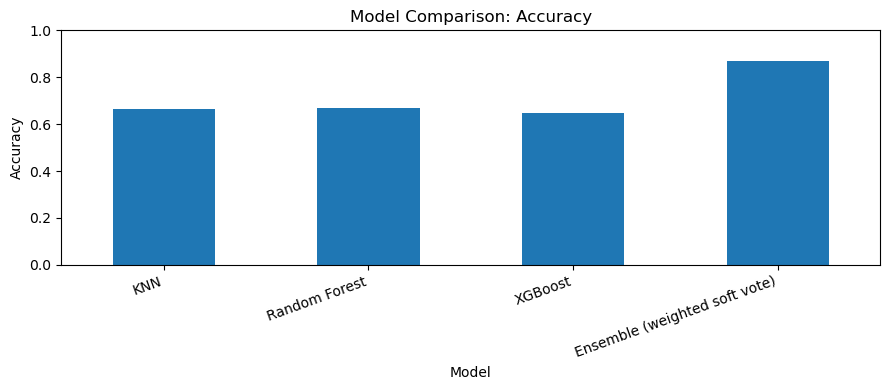

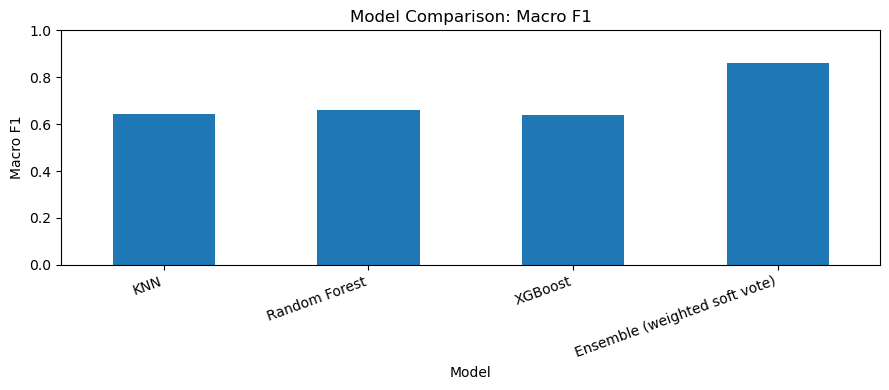

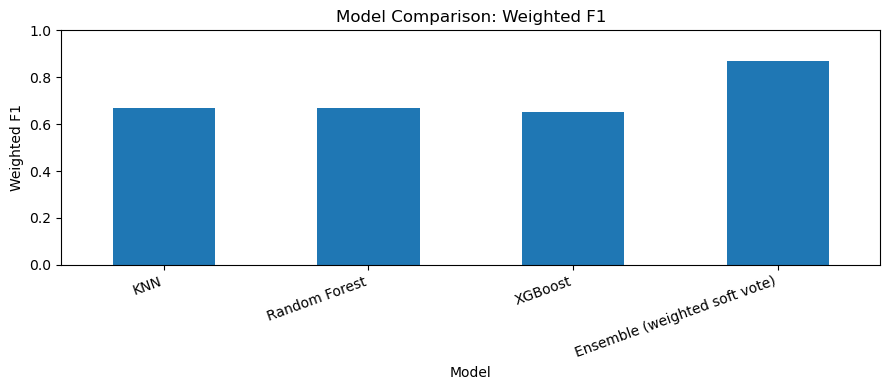

In [62]:
import matplotlib.pyplot as plt

for metric in ["Accuracy", "Macro F1", "Weighted F1"]:
    plt.figure(figsize=(9, 4))
    df_results[metric].plot(kind="bar")
    plt.ylabel(metric)
    plt.title(f"Model Comparison: {metric}")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


## Ensemble Model Analysis
Among all evaluated models, the weighted soft-voting ensemble achieved the best performance, significantly outperforming individual classifiers. In particular, the ensemble improved Macro F1 from approximately 0.66 (best single model) to 0.86, demonstrating the effectiveness of combining complementary decision boundaries.

# Final Result Visulisation

In [63]:
import pandas as pd

# Use the model result
data = {
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "KNN",
        "Random Forest",
        "XGBoost",
        "Ensemble"
    ],
    "Accuracy": [
        0.3644,
        0.1884,
        0.1860,
        0.5528,
        0.6636,
        0.6692,
        0.6481,
        0.8675
    ],
    "Macro F1": [
        0.36,
        0.09,
        0.08,
        0.54,
        0.65,
        0.66,
        0.64,
        0.8595
    ],
    "Weighted F1": [
        0.36,
        0.12,
        0.11,
        0.55,
        0.67,
        0.67,
        0.65,
        0.8675
    ]
}

df_perf = pd.DataFrame(data)
df_perf



,Model,Accuracy,Macro F1,Weighted F1
0,Naive Bayes,0.3644,0.3600,0.3600
1,Logistic Regression,0.1884,0.0900,0.1200
2,SVM,0.1860,0.0800,0.1100
3,Decision Tree,0.5528,0.5400,0.5500
4,KNN,0.6636,0.6500,0.6700
5,Random Forest,0.6692,0.6600,0.6700
6,XGBoost,0.6481,0.6400,0.6500
7,Ensemble,0.8675,0.8595,0.8675


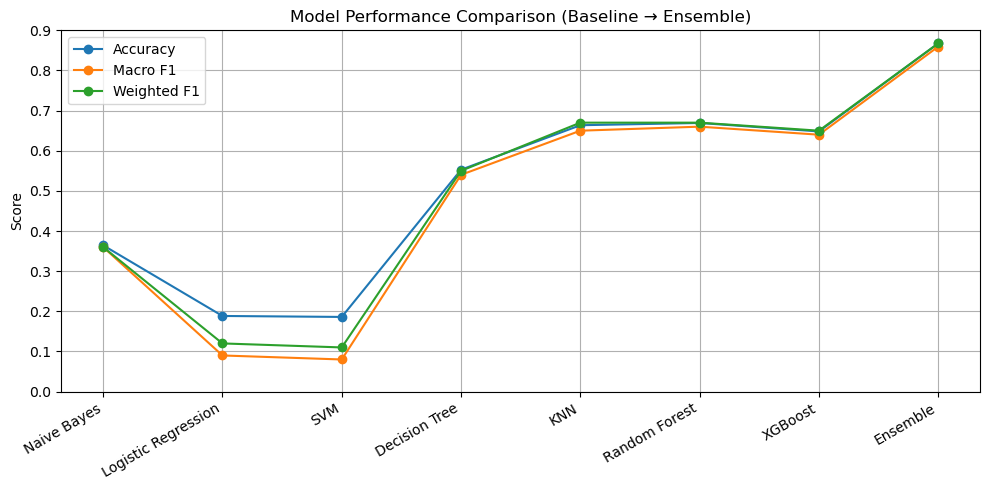

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(df_perf["Model"], df_perf["Accuracy"], marker="o", label="Accuracy")
plt.plot(df_perf["Model"], df_perf["Macro F1"], marker="o", label="Macro F1")
plt.plot(df_perf["Model"], df_perf["Weighted F1"], marker="o", label="Weighted F1")

plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.ylim(0, 0.9)
plt.title("Model Performance Comparison (Baseline → Ensemble)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


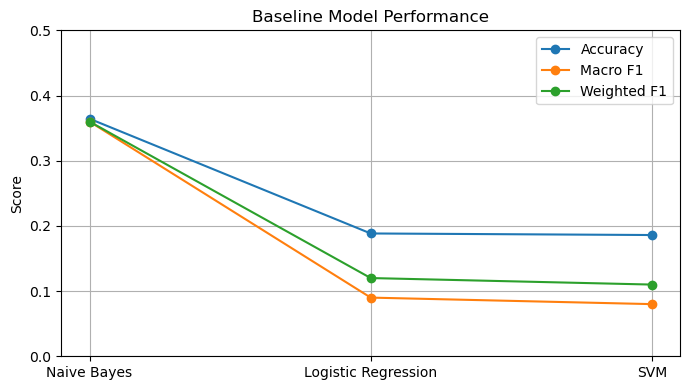

In [65]:
# Limitations of baseline models
baseline_df = df_perf.iloc[:3]  # NB, LR, SVM

plt.figure(figsize=(7, 4))
plt.plot(baseline_df["Model"], baseline_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(baseline_df["Model"], baseline_df["Macro F1"], marker="o", label="Macro F1")
plt.plot(baseline_df["Model"], baseline_df["Weighted F1"], marker="o", label="Weighted F1")

plt.ylim(0, 0.5)
plt.ylabel("Score")
plt.title("Baseline Model Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **Conclusion**
In this study, I investigated a multi-class gym exercise recognition problem using wearable sensor data. A range of machine learning models were applied and compared, including Naive Bayes, Logistic Regression, SVM, Decision Tree, KNN, Random Forest, and XGBoost. The goal was to understand how different modelling assumptions interact with sensor-based features and to identify an effective approach for classifying 11 exercise classes.

### 1. Performance of Individual Models

The experimental results showed that models based on linear decision boundaries or strong independence assumptions performed poorly on this dataset. Naive Bayes, Logistic Regression, and SVM all achieved low accuracy and Macro F1 scores, with some classes receiving almost no correct predictions. This outcome is consistent with the characteristics of the data, where sensor axes are highly correlated and exercise patterns overlap significantly. These conditions violate the assumptions required for linear or independence-based models to perform well.

In contrast, models capable of capturing nonlinear relationships showed clear improvements. The Decision Tree achieved moderate performance, indicating that rule-based nonlinear splits can partially separate exercise patterns. KNN and Random Forest further improved performance, reaching accuracy levels around 0.66–0.67. These models were particularly effective for exercises with repetitive and distinctive motion patterns, such as Running and Walking. XGBoost achieved comparable results, suggesting that boosting-based tree ensembles are also suitable for this type of data.

Overall, these results indicate that model flexibility and the ability to learn nonlinear structures are essential for sensor-based exercise classification.

### 2. Weighted Soft Voting Ensemble

While KNN, Random Forest, and XGBoost each performed reasonably well, none of them achieved consistently strong performance across all exercise classes. Each model showed different strengths depending on the type of movement being classified. This observation motivated the use of an ensemble approach.

A Weighted Soft Voting Ensemble was constructed by combining KNN, Random Forest, and XGBoost. Instead of relying on hard class predictions, the ensemble aggregates predicted class probabilities using weighted averaging. The weights were selected based on validation-set Macro F1 performance to prioritise balanced classification across all classes. The best-performing configuration assigned higher weights to KNN and Random Forest, with a lower weight for XGBoost.

This ensemble strategy allows complementary decision boundaries to be combined, reducing the weaknesses of individual models.

### 3. Final Results and Implications

The final ensemble model achieved an accuracy of 0.87, a Macro F1 score of 0.86, and a Weighted F1 score of 0.87 on the test set. Compared to the best single model, this represents a substantial improvement, particularly in Macro F1. This indicates that the ensemble achieved more balanced performance across exercise classes, including those with fewer samples.

These results show that ensemble learning is an effective strategy for complex sensor-based classification tasks, where class boundaries are highly overlapping and no single model performs optimally for all activities. In this context, Weighted Soft Voting proved to be a practical and robust approach for combining heterogeneous classifiers.

In conclusion, this project demonstrates that combining multiple nonlinear models through a carefully designed ensemble significantly improves exercise recognition performance compared to single-model approaches. Future work could extend this study by incorporating temporal sequence models, such as recurrent or attention-based architectures, or by exploring personalised models that adapt to individual users’ movement patterns.

### **Reference**
[1]Bian, S., Rey, V. F., Yuan, S., & Lukowicz, P. (2025). Hybrid CNN-dilated self-attention model using inertial and body-area electrostatic sensing for gym workout recognition, counting, and user authentication. arXiv. https://doi.org/10.48550/arXiv.2503.06311

[2]McKinney, W. (2018). Python for Data Analysis (2nd ed.): Data Wrangling with Pandas, NumPy, and IPython. O’Reilly Media

[3]https://archive.ics.uci.edu/dataset/1128/recgym:+gym+workouts+recognition+dataset+with+imu+and+capacitive+sensor-7

[4]https://www.kaggle.com/datasets/zhaxidelebsz/10-gym-exercises-with-615-abstracted-features

[5]https://github.com/zhaxidele/Toolkit-for-HBC-sensing/tree/main/Data/GymData

[6] Ng, A. (2018). Machine Learning Yearning. Deeplearning.ai. Available at: https://www.deeplearning.ai/machine-learning-yearning/